In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
purchase_behaviour = pd.read_csv('purchase_behaviour.csv')
transaction_data = pd.read_csv('transaction_data.csv')

In [28]:
purchase_behaviour.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [29]:
transaction_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [30]:
# Merge
merged_data = pd.merge(transaction_data, purchase_behaviour, on='LYLTY_CARD_NBR', how='inner')

# Display
merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [21]:
# Check for null values
print(merged_data.isnull().sum())

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [31]:
# Calculate total sales per product
product_profitability = (
    merged_data.groupby('PROD_NAME')['TOT_SALES']
    .sum()
    .sort_values(ascending=False)
)


In [39]:
product_profitability.head(10)

PROD_NAME
Dorito Corn Chp     Supreme 380g            40352.0
Smiths Crnkle Chip  Orgnl Big Bag 380g      36367.6
Smiths Crinkle Chips Salt & Vinegar 330g    34804.2
Kettle Mozzarella   Basil & Pesto 175g      34457.4
Smiths Crinkle      Original 330g           34302.6
Cheezels Cheese 330g                        34296.9
Doritos Cheese      Supreme 330g            33390.6
Kettle Sweet Chilli And Sour Cream 175g     33031.8
Kettle Original 175g                        32740.2
Kettle Sea Salt     And Vinegar 175g        32589.0
Name: TOT_SALES, dtype: float64

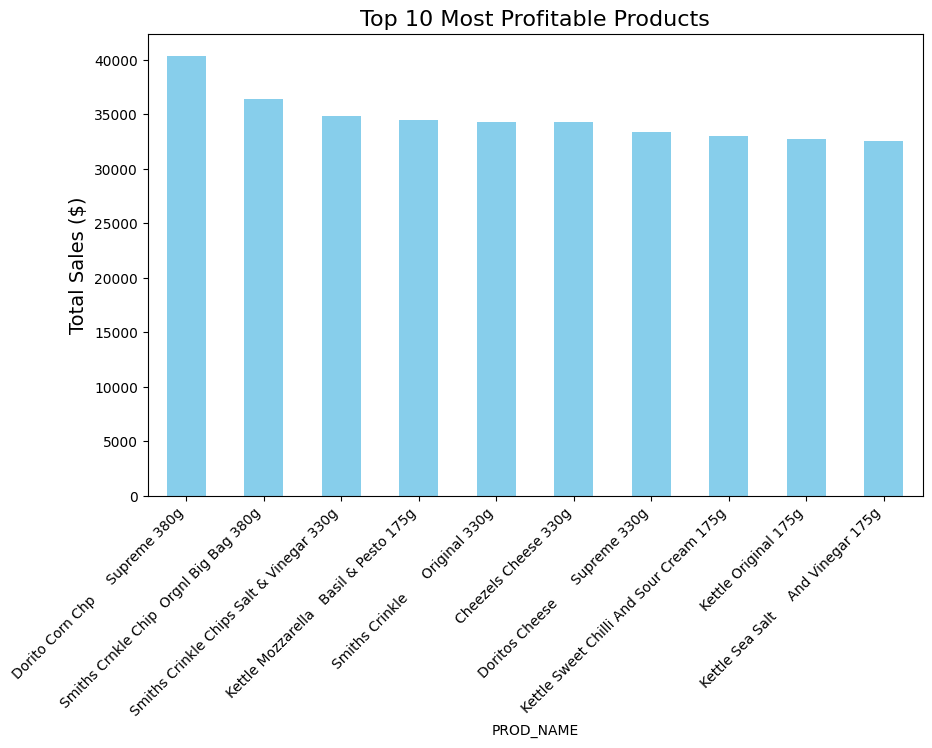

In [40]:
# Plot top 10 products by profitability
plt.figure(figsize=(10, 6))
product_profitability.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Profitable Products', fontsize=16)
plt.ylabel('Total Sales ($)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()


In [41]:
product_profitability.head(3)

PROD_NAME
Dorito Corn Chp     Supreme 380g            40352.0
Smiths Crnkle Chip  Orgnl Big Bag 380g      36367.6
Smiths Crinkle Chips Salt & Vinegar 330g    34804.2
Name: TOT_SALES, dtype: float64

In [42]:
# Calculate purchase frequency by customer segment
customer_loyalty = (
    merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TXN_ID']
    .count()
    .reset_index()
    .rename(columns={'TXN_ID': 'PURCHASE_COUNT'})
    .sort_values(by='PURCHASE_COUNT', ascending=False)
)

In [43]:
# Aggregate loyalty by segment
loyal_customer_segments = customer_loyalty.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PURCHASE_COUNT'].sum()

# Display most loyal customer segments
print("Most Loyal Customer Segments:")
print(loyal_customer_segments)


Most Loyal Customer Segments:
LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget               5020
                        Mainstream          11874
                        Premium              8216
NEW FAMILIES            Budget               3005
                        Mainstream           2325
                        Premium              1589
OLDER FAMILIES          Budget              23160
                        Mainstream          14244
                        Premium             11192
OLDER SINGLES/COUPLES   Budget              18407
                        Mainstream          18318
                        Premium             17754
RETIREES                Budget              15201
                        Mainstream          21466
                        Premium             13096
YOUNG FAMILIES          Budget              19122
                        Mainstream          12907
                        Premium             11563
YOUNG SINGLES/COUPLES   Budge

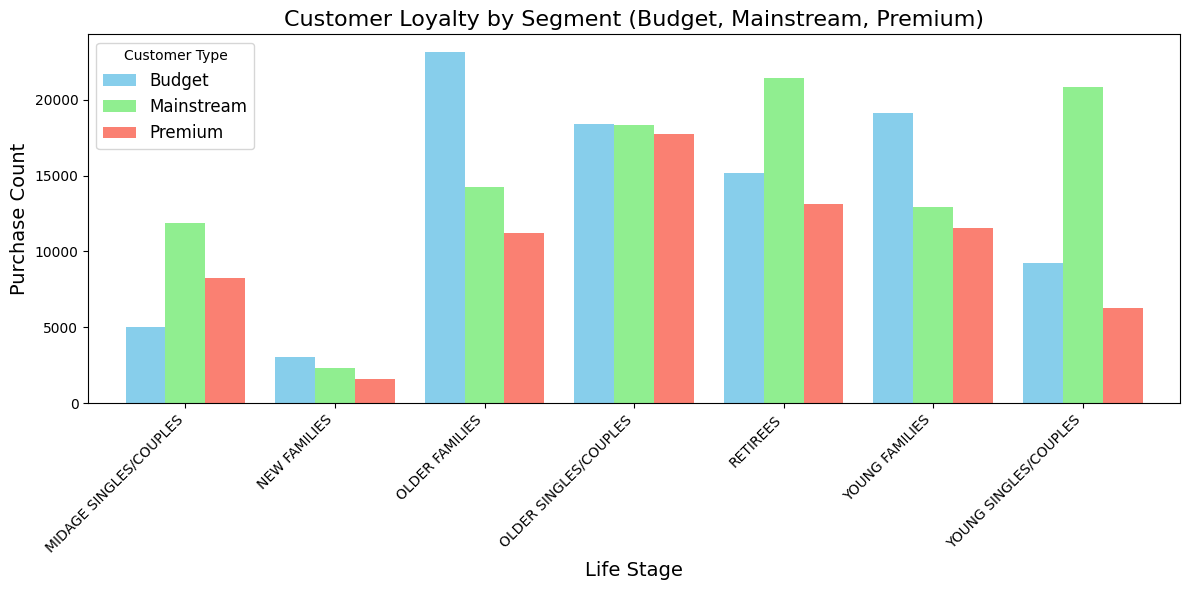

In [11]:
# Prepare data for grouped bar chart
loyalty_data = customer_loyalty.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PURCHASE_COUNT'].sum().reset_index()

# Pivot data for grouped bar chart
loyalty_pivot = loyalty_data.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='PURCHASE_COUNT')

# Plot grouped bar chart
loyalty_pivot.plot(kind='bar', figsize=(12, 6), width=0.8, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Customer Loyalty by Segment (Budget, Mainstream, Premium)', fontsize=16)
plt.ylabel('Purchase Count', fontsize=14)
plt.xlabel('Life Stage', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Type', fontsize=12)
plt.tight_layout()
plt.show()


In [54]:
print("From my analysis may be the top 3 Most Profitable Products:")
print("Dorito Corn Chip Supreme 380g with Total sales of 40,352")
print("Smiths Crinkle Chip Original Big Bag 380g with Total sales of 36,367.6")
print("Smiths Crinkle Chips Salt & Vinegar 330g with Total sales of 34,804.2") 
print("")
print("Refer Top Profitable Products graph for better understanding to profitable products")
print("")
print("And most loyal customers are:")
print("Older Families (Budget): Highest purchase count (23,160 transactions).")
print("Retirees (Mainstream): Second highest (21,466 transactions).")
print("")
print("Refer Customer Loyalty graph for detailed analysis")

From my analysis may be the top 3 Most Profitable Products:
Dorito Corn Chip Supreme 380g with Total sales of 40,352
Smiths Crinkle Chip Original Big Bag 380g with Total sales of 36,367.6
Smiths Crinkle Chips Salt & Vinegar 330g with Total sales of 34,804.2

Refer Top Profitable Products graph for better understanding to profitable products

And most loyal customers are:
Older Families (Budget): Highest purchase count (23,160 transactions).
Retirees (Mainstream): Second highest (21,466 transactions).

Refer Customer Loyalty graph for detailed analysis
